In [7]:
import pandas as pd
import requests
import math
import matplotlib.pyplot as plt

In [2]:
MAX_RESULTS_PER_PAGE = 200
BASE_URL = 'https://api.openalex.org/works?search='
keywords = '("DNA" AND "foundation model") OR ("DNABERT")'

In [8]:
def get_request(url: str):
    """Returns metadata and results of a OpenAlex API query

    Args:
        url (str): query for OpenAlex API

    Returns:
        dict: Combined metadata from all pages
        list: Combined results from all pages
    """
    all_results = []
    current_page = 1
    total_pages = None

    while True:
        paginated_url = f"{url}&page={current_page}"
        
        response = requests.get(paginated_url)
        
        if response.status_code == 200:
            data = response.json()
            if current_page == 1:
                meta = data['meta']
                total_pages = math.ceil(meta['count'] / MAX_RESULTS_PER_PAGE)
            
            results = data['results']    
            all_results.extend(results) 
                
            if current_page >= total_pages:
                break
            
            current_page += 1
            
        else:
            print(f"Error: {response.status_code}")
            break
    
    return meta, all_results

In [10]:
query = f'{BASE_URL}{keywords}&per-page={MAX_RESULTS_PER_PAGE}'

In [11]:
meta, reports = get_request(query)

In [12]:
meta

{'count': 854,
 'db_response_time_ms': 512,
 'page': 1,
 'per_page': 200,
 'groups_count': None}

In [14]:
columns_to_keep = ['doi','title','relevance_score', 'publication_year', 'publication_date', 'cited_by_count']
result_df = pd.json_normalize(reports)[columns_to_keep]

In [15]:
n_original = meta['count']
print(f"n original: {n_original}")
result_df = result_df[~result_df.duplicated(subset=['doi'])]
print(f"n after removing duplicates doi: {len(result_df)}")

result_df = result_df[result_df['publication_year']>=2017]
print(f"n after filtering >= 2017: {len(result_df)}")

n original: 854
n after removing duplicates doi: 849
n after filtering >= 2017: 477


In [41]:
result_df.to_csv('openalex_initialsearchgg.csv', index=False)

## Summary Stats

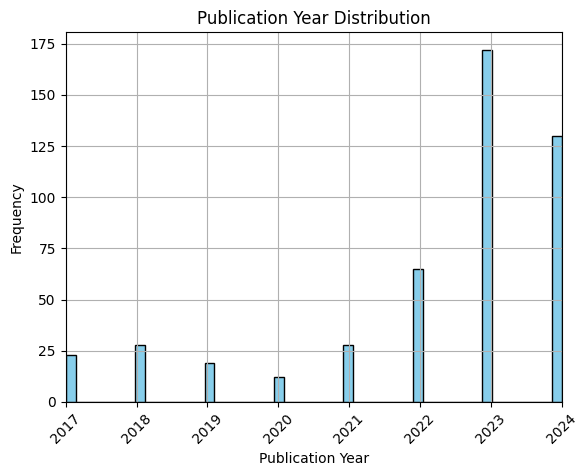

In [20]:
result_df['publication_year'].hist(bins=50, color='skyblue', edgecolor='black')

# Set titles and labels
plt.title('Publication Year Distribution')
plt.xlabel('Publication Year')
plt.ylabel('Frequency')

# Adjust the number of ticks on the x-axis
plt.xticks(ticks=range(result_df['publication_year'].min(), result_df['publication_year'].max() + 1, 1), rotation=45)
plt.xlim(2017,2024)

# Show the plot
plt.show()

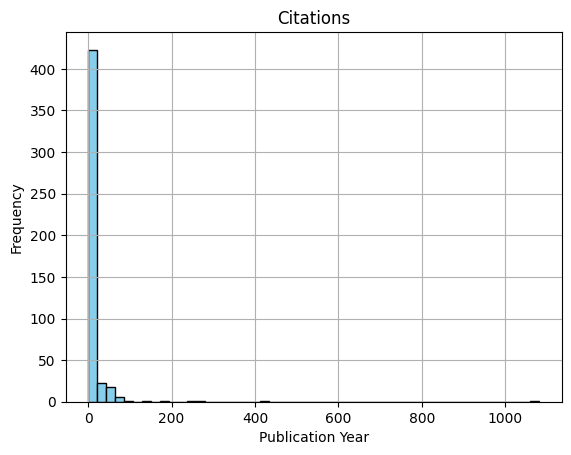

In [21]:
result_df['cited_by_count'].hist(bins=50, color='skyblue', edgecolor='black')

# Set titles and labels
plt.title('Citations')
plt.xlabel('Publication Year')
plt.ylabel('Frequency')

# Show the plot
plt.show()